# Delta Forecasting, Transition Detection, and Regime Analysis

This notebook investigates why absolute-level models did not beat persistence and tests whether process measurements can predict **departures from the current `SLURRY_FREE_ACID` value**.

For each horizon (h\in\{1,5,10,15\}):

\[
\Delta y_{t,h}=y_{t+h}-y_t,
\qquad
\hat y_{t+h}=y_t+\widehat{\Delta y}_{t,h}.
\]

Persistence is exactly the zero-change forecast. All transition definitions, preprocessing, model choices, and thresholds are determined without test-set fitting. Candidate regimes are analytical labels, not confirmed plant events.


## 1. Configuration and reproducibility


### 1.1 Imports


In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, median_absolute_error,
                             r2_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


### 1.2 Central configuration


In [2]:
RANDOM_STATE = 42
HORIZONS = [1, 5, 10, 15]
EXPERIMENTS = ["A_exogenous_raw", "D_exogenous_full", "E_target_history", "F_hybrid_full"]
TARGET_LAGS = [0, 1, 2, 5, 10, 15, 30]
MODELS = ["ridge", "extra_trees"]
RIDGE_ALPHAS = [1.0, 10.0]
TREE_CANDIDATES = [
    {"n_estimators": 40, "min_samples_leaf": 2, "max_features": 0.8},
    {"n_estimators": 40, "min_samples_leaf": 5, "max_features": 0.7},
]
TRANSITION_QUANTILE = 0.90
EXTREME_QUANTILE = 0.95
PERMUTATION_ROWS = 2000

PREPARATION_NOTEBOOK = Path("02_feature_engineering_data_preparation.ipynb")
NOTEBOOK03_RESULTS = Path("../reports/prediction_benchmark_artifacts/complete_benchmark_results.csv")
OUTPUT_DIR = Path("../reports/delta_transition_artifacts")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for path in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")


### 1.3 Experimental questions


In [3]:
experiment_questions = pd.DataFrame([
    {"comparison": "zero change vs delta regression", "meaning": "Can the model beat persistence directly?"},
    {"comparison": "A vs D", "meaning": "Do accepted temporal/process features help exogenous prediction?"},
    {"comparison": "E vs F", "meaning": "Do process measurements add value beyond target history?"},
    {"comparison": "unweighted vs transition-weighted", "meaning": "Does emphasizing movement improve transition performance?"},
    {"comparison": "two-stage warning", "meaning": "Can meaningful departures be detected with useful precision and recall?"},
])
display(experiment_questions)


,comparison,meaning
0,zero change vs delta regression,Can the model beat persistence directly?
1,A vs D,Do accepted temporal/process features help exo...
2,E vs F,Do process measurements add value beyond targe...
3,unweighted vs transition-weighted,Does emphasizing movement improve transition p...
4,two-stage warning,Can meaningful departures be detected with use...


## 2. Recover the verified preparation foundation


### 2.1 Replay Notebook 02 without changing its methodology


In [4]:
def recover_prepared_namespace(notebook_path):
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    namespace = {"display": lambda value: None}
    executed = 0
    with redirect_stdout(StringIO()):
        for cell in notebook["cells"]:
            if cell.get("cell_type") != "code":
                continue
            source = cell.get("source", "")
            source = "".join(source) if isinstance(source, list) else source
            if source.strip().startswith("import matplotlib.pyplot as plt"):
                break
            exec(compile(source, f"preparation_cell_{executed}", "exec"), namespace)
            executed += 1
    return namespace, executed


prep, replayed_cells = recover_prepared_namespace(PREPARATION_NOTEBOOK)
modeling_datasets = prep["modeling_datasets"]
prepared = prep["prepared"]
raw_process_df = prep["df"].copy()
TIME_COL = prep["TIME_COL"]
TARGET = prep["TARGET"]
print(f"Recovered {len(modeling_datasets)} prepared configurations from {replayed_cells} preparation cells.")


Recovered 16 prepared configurations from 37 preparation cells.


### 2.2 Confirm the 16 inherited configurations


In [5]:
expected_prepared_keys = {(h, fs) for h in HORIZONS for fs in ["A_raw", "B_temporal", "C_process", "D_full"]}
assert set(modeling_datasets) == expected_prepared_keys

integrity_rows = []
for key in sorted(expected_prepared_keys):
    h, fs = key
    ds, parts = modeling_datasets[key], prepared[key]
    integrity_rows.append({
        "horizon_min": h, "feature_set": fs,
        "chronological": parts["train_df"][TIME_COL].max() < parts["valid_df"][TIME_COL].min() < parts["test_df"][TIME_COL].min(),
        "aligned": all(list(ds["X"]["tree"][0].columns) == list(frame.columns) for frame in ds["X"]["tree"]),
        "no_missing": all(not frame.isna().any().any() for variant in ds["X"].values() for frame in variant),
        "no_future_target": not any(c == TARGET or c.startswith(TARGET + "_t_plus_") for c in ds["features"]),
        "feature_count": len(ds["features"]),
    })
input_integrity = pd.DataFrame(integrity_rows)
assert input_integrity[["chronological", "aligned", "no_missing", "no_future_target"]].all().all()
display(input_integrity)


,horizon_min,feature_set,chronological,aligned,no_missing,no_future_target,feature_count
0,1,A_raw,True,True,True,True,21
1,1,B_temporal,True,True,True,True,162
2,1,C_process,True,True,True,True,58
3,1,D_full,True,True,True,True,178
4,5,A_raw,True,True,True,True,21
5,5,B_temporal,True,True,True,True,162
6,5,C_process,True,True,True,True,58
7,5,D_full,True,True,True,True,178
8,10,A_raw,True,True,True,True,21
9,10,B_temporal,True,True,True,True,162


### 2.3 Observations


- Notebook 04 inherits the exact chronological rows, selected features, and train-fitted preprocessing from Notebook 02.
- New target-history features are added only in explicitly named autoregressive experiments E and F.
- No future target value is used as an input.


## 3. Construct leakage-safe delta targets and target history


### 3.1 Build current and past target lookup


In [6]:
raw_process_df = raw_process_df.sort_values(TIME_COL).reset_index(drop=True)
target_history_frame = raw_process_df[[TIME_COL, TARGET]].copy()
for lag in TARGET_LAGS:
    name = f"{TARGET}_current" if lag == 0 else f"{TARGET}_lag_{lag}"
    target_history_frame[name] = raw_process_df[TARGET].shift(lag)
target_history_frame[f"{TARGET}_diff_5"] = raw_process_df[TARGET] - raw_process_df[TARGET].shift(5)
target_history_frame[f"{TARGET}_roll_mean_10"] = raw_process_df[TARGET].rolling(10, min_periods=10).mean()
target_history_frame[f"{TARGET}_roll_std_10"] = raw_process_df[TARGET].rolling(10, min_periods=10).std()
target_history_frame = target_history_frame.set_index(TIME_COL)
TARGET_HISTORY_FEATURES = [c for c in target_history_frame.columns if c != TARGET]
assert not any("t_plus" in c for c in TARGET_HISTORY_FEATURES)
display(pd.DataFrame({"target_history_feature": TARGET_HISTORY_FEATURES, "availability": "time t or earlier"}))


,target_history_feature,availability
0,SLURRY_FREE_ACID_current,time t or earlier
1,SLURRY_FREE_ACID_lag_1,time t or earlier
2,SLURRY_FREE_ACID_lag_2,time t or earlier
3,SLURRY_FREE_ACID_lag_5,time t or earlier
4,SLURRY_FREE_ACID_lag_10,time t or earlier
5,SLURRY_FREE_ACID_lag_15,time t or earlier
6,SLURRY_FREE_ACID_lag_30,time t or earlier
7,SLURRY_FREE_ACID_diff_5,time t or earlier
8,SLURRY_FREE_ACID_roll_mean_10,time t or earlier
9,SLURRY_FREE_ACID_roll_std_10,time t or earlier


### 3.2 Assemble four separately named experiment families


In [7]:
def history_for_timestamps(timestamps):
    return target_history_frame.reindex(pd.Index(timestamps))[TARGET_HISTORY_FEATURES].reset_index(drop=True)


delta_experiments = {}
dimension_rows = []
for h in HORIZONS:
    for experiment in EXPERIMENTS:
        source_set = "A_raw" if experiment == "A_exogenous_raw" else "D_full"
        base = modeling_datasets[(h, source_set)]
        parts = prepared[(h, source_set)]
        include_process = experiment in ["A_exogenous_raw", "D_exogenous_full", "F_hybrid_full"]
        include_history = experiment in ["E_target_history", "F_hybrid_full"]
        split_payload = {}
        history_scaler = StandardScaler() if include_history else None
        raw_histories = {s: history_for_timestamps(parts[f"{s}_df"][TIME_COL]) for s in ["train", "valid", "test"]}
        usable_masks = {s: raw_histories[s][f"{TARGET}_current"].notna().reset_index(drop=True)
                        for s in ["train", "valid", "test"]}
        history_imputer = SimpleImputer(strategy="median")
        history_imputer.fit(raw_histories["train"].loc[usable_masks["train"]])
        histories = {s: pd.DataFrame(history_imputer.transform(raw_histories[s]), columns=TARGET_HISTORY_FEATURES)
                     for s in ["train", "valid", "test"]}
        if include_history:
            scaled_train = pd.DataFrame(history_scaler.fit_transform(histories["train"]), columns=TARGET_HISTORY_FEATURES)
            scaled_valid = pd.DataFrame(history_scaler.transform(histories["valid"]), columns=TARGET_HISTORY_FEATURES)
            scaled_test = pd.DataFrame(history_scaler.transform(histories["test"]), columns=TARGET_HISTORY_FEATURES)
            scaled_histories = {"train": scaled_train, "valid": scaled_valid, "test": scaled_test}
        for idx, split in enumerate(["train", "valid", "test"]):
            mask = usable_masks[split]
            timestamp = parts[f"{split}_df"][TIME_COL].reset_index(drop=True).loc[mask].reset_index(drop=True)
            current_y = raw_histories[split][f"{TARGET}_current"].loc[mask].reset_index(drop=True)
            future_y = base[f"y_{split}"].reset_index(drop=True).loc[mask].reset_index(drop=True)
            delta_y = future_y - current_y
            tree_parts, standard_parts = [], []
            if include_process:
                tree_parts.append(base["X"]["tree"][idx].reset_index(drop=True).loc[mask].reset_index(drop=True))
                standard_parts.append(base["X"]["standard"][idx].reset_index(drop=True).loc[mask].reset_index(drop=True))
            if include_history:
                tree_parts.append(histories[split].loc[mask].reset_index(drop=True))
                standard_parts.append(scaled_histories[split].loc[mask].reset_index(drop=True))
            X_tree = pd.concat(tree_parts, axis=1)
            X_standard = pd.concat(standard_parts, axis=1)
            assert list(X_tree.columns) == list(X_standard.columns)
            split_payload[split] = {"timestamp": timestamp, "current_y": current_y, "future_y": future_y,
                                    "delta_y": delta_y, "X_tree": X_tree, "X_standard": X_standard}
        delta_experiments[(h, experiment)] = {"splits": split_payload, "history_scaler": history_scaler,
                                              "history_imputer": history_imputer, "source_set": source_set,
                                              "features": list(split_payload["train"]["X_tree"].columns)}
        dimension_rows.append({"horizon_min": h, "experiment": experiment,
                               "feature_count": len(split_payload["train"]["X_tree"].columns),
                               **{f"{s}_rows": len(split_payload[s]["delta_y"]) for s in ["train", "valid", "test"]}})

delta_dimensions = pd.DataFrame(dimension_rows)
assert len(delta_experiments) == 16
display(delta_dimensions)


,horizon_min,experiment,feature_count,train_rows,valid_rows,test_rows
0,1,A_exogenous_raw,21,30940,6628,6632
1,1,D_exogenous_full,178,30940,6628,6632
2,1,E_target_history,10,30940,6628,6632
3,1,F_hybrid_full,188,30940,6628,6632
4,5,A_exogenous_raw,21,30928,6624,6631
5,5,D_exogenous_full,178,30928,6624,6631
6,5,E_target_history,10,30928,6624,6631
7,5,F_hybrid_full,188,30928,6624,6631
8,10,A_exogenous_raw,21,30915,6618,6630
9,10,D_exogenous_full,178,30915,6618,6630


### 3.3 Validate delta identity and timestamp alignment


In [8]:
delta_identity_checks = []
for (h, experiment), payload in delta_experiments.items():
    for split, data in payload["splits"].items():
        delta_identity_checks.append({
            "horizon_min": h, "experiment": experiment, "split": split,
            "delta_identity": np.allclose(data["delta_y"] + data["current_y"], data["future_y"]),
            "columns_aligned": list(data["X_tree"].columns) == list(data["X_standard"].columns),
            "no_missing": not data["X_tree"].isna().any().any() and not data["X_standard"].isna().any().any(),
            "unique_timestamps": data["timestamp"].is_unique,
        })
delta_identity_checks = pd.DataFrame(delta_identity_checks)
assert delta_identity_checks[["delta_identity", "columns_aligned", "no_missing", "unique_timestamps"]].all().all()
display(delta_identity_checks.groupby(["horizon_min", "experiment"])[["delta_identity", "columns_aligned", "no_missing"]].all())


delta_identity  columns_aligned  no_missing
horizon_min experiment                                                   
1           A_exogenous_raw             True             True        True
            D_exogenous_full            True             True        True
            E_target_history            True             True        True
            F_hybrid_full               True             True        True
5           A_exogenous_raw             True             True        True
            D_exogenous_full            True             True        True
            E_target_history            True             True        True
            F_hybrid_full               True             True        True
10          A_exogenous_raw             True             True        True
            D_exogenous_full            True             True        True
            E_target_history            True             True        True
            F_hybrid_full               True             True        True
15          A_exogenous_raw             True             True        True
            D_exogenous_full            True             True        True
            E_target_history            True             True        True
            F_hybrid_full               True             True        True

## 4. Diagnose distribution shift before modeling


### 4.1 Compare target and feature distributions


In [9]:
def standardized_mean_difference(train, other):
    denom = float(np.nanstd(train, ddof=1))
    return (float(np.nanmean(other)) - float(np.nanmean(train))) / (denom + 1e-12)


shift_rows = []
for h in HORIZONS:
    payload = delta_experiments[(h, "D_exogenous_full")]["splits"]
    for split in ["valid", "test"]:
        for name, train_values, other_values in [
            ("future_target", payload["train"]["future_y"], payload[split]["future_y"]),
            ("delta_target", payload["train"]["delta_y"], payload[split]["delta_y"]),
        ]:
            shift_rows.append({"horizon_min": h, "split": split, "variable": name,
                               "train_mean": np.mean(train_values), "comparison_mean": np.mean(other_values),
                               "standardized_mean_difference": standardized_mean_difference(train_values, other_values)})
distribution_shift_summary = pd.DataFrame(shift_rows)

feature_shift_rows = []
for h in HORIZONS:
    p = delta_experiments[(h, "D_exogenous_full")]["splits"]
    for split in ["valid", "test"]:
        for feature in p["train"]["X_tree"].columns:
            smd = standardized_mean_difference(p["train"]["X_tree"][feature], p[split]["X_tree"][feature])
            feature_shift_rows.append({"horizon_min": h, "split": split, "feature": feature, "abs_smd": abs(smd), "smd": smd})
feature_shift = pd.DataFrame(feature_shift_rows).sort_values("abs_smd", ascending=False)
display(distribution_shift_summary)
display(feature_shift.head(20))


,horizon_min,split,variable,train_mean,comparison_mean,standardized_mean_difference
0,1,valid,future_target,11.321178,11.154412,-0.310587
1,1,valid,delta_target,-0.000041,0.000118,0.000373
2,1,test,future_target,11.321178,11.330080,0.016579
3,1,test,delta_target,-0.000041,-0.000202,-0.000375
4,5,valid,future_target,11.321129,11.153891,-0.311498
5,5,valid,delta_target,0.000007,0.000209,0.000443
6,5,test,future_target,11.321129,11.329741,0.016039
7,5,test,delta_target,0.000007,-0.000859,-0.001898
8,10,valid,future_target,11.320944,11.153304,-0.312125
9,10,valid,delta_target,-0.000191,0.000421,0.001293


,horizon_min,split,feature,abs_smd,smd
1252,15,test,FLOW_RATE_PHOSPHORIC_ACID_1_lag_10,0.963774,0.963774
896,10,test,FLOW_RATE_PHOSPHORIC_ACID_1_lag_10,0.961401,0.961401
540,5,test,FLOW_RATE_PHOSPHORIC_ACID_1_lag_10,0.959271,0.959271
1251,15,test,FLOW_RATE_PHOSPHORIC_ACID_1,0.959245,0.959245
184,1,test,FLOW_RATE_PHOSPHORIC_ACID_1_lag_10,0.957682,0.957682
895,10,test,FLOW_RATE_PHOSPHORIC_ACID_1,0.957008,0.957008
539,5,test,FLOW_RATE_PHOSPHORIC_ACID_1,0.954671,0.954671
183,1,test,FLOW_RATE_PHOSPHORIC_ACID_1,0.953194,0.953194
1253,15,test,FLOW_RATE_PHOSPHORIC_ACID_1_roll_mean_10,0.933623,0.933623
897,10,test,FLOW_RATE_PHOSPHORIC_ACID_1_roll_mean_10,0.931320,0.931320


### 4.2 Observations


In [10]:
large_shift = feature_shift.query("split == 'test' and abs_smd >= 0.5")
print(f"Features with |standardized mean difference| >= 0.5 in test: {large_shift['feature'].nunique()}")
print("These are distribution-shift signals, not proof of a process-grade or causal change.")


Features with |standardized mean difference| >= 0.5 in test: 8
These are distribution-shift signals, not proof of a process-grade or causal change.


## 5. Metrics, transition definitions, and baselines


### 5.1 Metric functions


In [11]:
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    error = y_pred - y_true
    ae = np.abs(error)
    return {"mae": mean_absolute_error(y_true, y_pred),
            "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
            "median_ae": median_absolute_error(y_true, y_pred),
            "r2": r2_score(y_true, y_pred), "bias": error.mean(),
            "p90_ae": np.quantile(ae, .90), "p95_ae": np.quantile(ae, .95)}


def prefixed(metrics, prefix):
    return {f"{prefix}_{k}": v for k, v in metrics.items()}


### 5.2 Derive training-only transition and extreme thresholds


In [12]:
threshold_rows = []
thresholds = {}
for h in HORIZONS:
    train_delta = delta_experiments[(h, "A_exogenous_raw")]["splits"]["train"]["delta_y"]
    transition = float(np.quantile(np.abs(train_delta), TRANSITION_QUANTILE))
    extreme = float(np.quantile(np.abs(train_delta), EXTREME_QUANTILE))
    thresholds[h] = {"transition": transition, "extreme": extreme}
    threshold_rows.append({"horizon_min": h, "transition_quantile": TRANSITION_QUANTILE,
                           "transition_abs_delta_threshold": transition, "extreme_quantile": EXTREME_QUANTILE,
                           "extreme_abs_delta_threshold": extreme})
transition_thresholds = pd.DataFrame(threshold_rows)
display(transition_thresholds)


,horizon_min,transition_quantile,transition_abs_delta_threshold,extreme_quantile,extreme_abs_delta_threshold
0,1,0.9,0.283,0.95,0.347
1,5,0.9,0.383,0.95,0.465
2,10,0.9,0.429,0.95,0.522
3,15,0.9,0.440,0.95,0.542


### 5.3 Evaluate zero-change persistence


In [13]:
persistence_rows = []
for h in HORIZONS:
    p = delta_experiments[(h, "A_exogenous_raw")]["splits"]
    row = {"horizon_min": h, "model": "persistence_zero_delta"}
    for split in ["valid", "test"]:
        row.update(prefixed(regression_metrics(p[split]["future_y"], p[split]["current_y"]), split))
        event = np.abs(p[split]["delta_y"]) >= thresholds[h]["transition"]
        row[f"{split}_transition_rmse"] = mean_squared_error(p[split]["future_y"][event], p[split]["current_y"][event]) ** .5
        row[f"{split}_transition_rows"] = int(event.sum())
    persistence_rows.append(row)
persistence_results = pd.DataFrame(persistence_rows)
display(persistence_results)


,horizon_min,model,valid_mae,valid_rmse,valid_median_ae,valid_r2,valid_bias,valid_p90_ae,valid_p95_ae,valid_transition_rmse,valid_transition_rows,test_mae,test_rmse,test_median_ae,test_r2,test_bias,test_p90_ae,test_p95_ae,test_transition_rmse,test_transition_rows
0,1,persistence_zero_delta,0.150448,0.227716,0.121,0.730151,-0.000118,0.3040,0.36500,0.532702,837,0.137558,0.196755,0.110,0.811818,0.000202,0.2740,0.33300,0.503367,599
1,5,persistence_zero_delta,0.198799,0.277921,0.162,0.597611,-0.000209,0.4030,0.48385,0.631924,777,0.181389,0.249125,0.145,0.698103,0.000859,0.3670,0.45000,0.613577,595
2,10,persistence_zero_delta,0.220871,0.302425,0.183,0.521984,-0.000421,0.4493,0.54015,0.675822,782,0.204727,0.279756,0.165,0.619330,0.001063,0.4180,0.51000,0.684290,603
3,15,persistence_zero_delta,0.225093,0.304459,0.186,0.515502,-0.000778,0.4590,0.54700,0.680593,750,0.215175,0.296015,0.169,0.574107,0.001816,0.4341,0.52855,0.719654,636


## 6. Direct delta-regression benchmark


### 6.1 Controlled, equal-budget tuning


In [14]:
MODEL_SPECS = {
    "ridge": {"variant": "X_standard", "candidates": [{"alpha": x} for x in RIDGE_ALPHAS]},
    "extra_trees": {"variant": "X_tree", "candidates": TREE_CANDIDATES},
}


def make_model(name, params):
    if name == "ridge":
        return Ridge(**params)
    return ExtraTreesRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)


search_rows, selected_rows, prediction_frames, fitted_models = [], [], [], {}
for (h, experiment), payload in sorted(delta_experiments.items()):
    splits = payload["splits"]
    persistence_valid_rmse = float(persistence_results.query("horizon_min == @h")["valid_rmse"].iloc[0])
    persistence_test_rmse = float(persistence_results.query("horizon_min == @h")["test_rmse"].iloc[0])
    for model_name, spec in MODEL_SPECS.items():
        candidates = []
        for candidate_id, params in enumerate(spec["candidates"], 1):
            model = make_model(model_name, params)
            start = time.perf_counter()
            model.fit(splits["train"][spec["variant"]], splits["train"]["delta_y"])
            fit_seconds = time.perf_counter() - start
            valid_delta_pred = model.predict(splits["valid"][spec["variant"]])
            valid_level_pred = splits["valid"]["current_y"].to_numpy() + valid_delta_pred
            metrics = regression_metrics(splits["valid"]["future_y"], valid_level_pred)
            candidate = {"horizon_min": h, "experiment": experiment, "model": model_name,
                         "candidate_id": candidate_id, "parameters": json.dumps(params, sort_keys=True),
                         "fit_seconds": fit_seconds, **prefixed(metrics, "valid")}
            search_rows.append(candidate)
            candidates.append((metrics["rmse"], candidate_id, params, model, valid_delta_pred, fit_seconds))
        _, selected_id, selected_params, model, valid_delta_pred, fit_seconds = min(candidates, key=lambda x: x[0])
        test_start = time.perf_counter()
        test_delta_pred = model.predict(splits["test"][spec["variant"]])
        test_inference = time.perf_counter() - test_start
        valid_level_pred = splits["valid"]["current_y"].to_numpy() + valid_delta_pred
        test_level_pred = splits["test"]["current_y"].to_numpy() + test_delta_pred
        valid_metrics = regression_metrics(splits["valid"]["future_y"], valid_level_pred)
        test_metrics = regression_metrics(splits["test"]["future_y"], test_level_pred)
        event_valid = np.abs(splits["valid"]["delta_y"]) >= thresholds[h]["transition"]
        event_test = np.abs(splits["test"]["delta_y"]) >= thresholds[h]["transition"]
        row = {"horizon_min": h, "experiment": experiment, "model": model_name,
               "feature_count": len(payload["features"]), "selected_candidate_id": selected_id,
               "selected_parameters": json.dumps(selected_params, sort_keys=True), "training_seconds": fit_seconds,
               "test_inference_seconds": test_inference,
               "valid_improvement_over_persistence_pct": 100 * (persistence_valid_rmse - valid_metrics["rmse"]) / persistence_valid_rmse,
               "test_improvement_over_persistence_pct": 100 * (persistence_test_rmse - test_metrics["rmse"]) / persistence_test_rmse,
               "valid_transition_rmse": mean_squared_error(splits["valid"]["future_y"][event_valid], valid_level_pred[event_valid]) ** .5,
               "test_transition_rmse": mean_squared_error(splits["test"]["future_y"][event_test], test_level_pred[event_test]) ** .5,
               **prefixed(valid_metrics, "valid"), **prefixed(test_metrics, "test")}
        selected_rows.append(row)
        fitted_models[(h, experiment, model_name)] = model
        for split, delta_pred, level_pred in [("valid", valid_delta_pred, valid_level_pred), ("test", test_delta_pred, test_level_pred)]:
            prediction_frames.append(pd.DataFrame({"timestamp": splits[split]["timestamp"], "horizon_min": h,
                "experiment": experiment, "model": model_name, "split": split,
                "current_target": splits[split]["current_y"], "actual_future_target": splits[split]["future_y"],
                "actual_delta": splits[split]["delta_y"], "predicted_delta": delta_pred,
                "predicted_future_target": level_pred}))

delta_search_results = pd.DataFrame(search_rows)
delta_benchmark_results = pd.DataFrame(selected_rows)
delta_predictions = pd.concat(prediction_frames, ignore_index=True)
display(delta_benchmark_results.sort_values(["horizon_min", "valid_rmse"]))


,horizon_min,experiment,model,feature_count,selected_candidate_id,selected_parameters,training_seconds,test_inference_seconds,valid_improvement_over_persistence_pct,test_improvement_over_persistence_pct,valid_transition_rmse,test_transition_rmse,valid_mae,valid_rmse,valid_median_ae,valid_r2,valid_bias,valid_p90_ae,valid_p95_ae,test_mae,test_rmse,test_median_ae,test_r2,test_bias,test_p90_ae,test_p95_ae
6,1,F_hybrid_full,ridge,188,2,"{""alpha"": 10.0}",0.182320,0.018273,27.066901,23.166882,0.334502,0.301077,0.107803,0.166081,0.085293,0.856461,0.014922,0.218781,0.269802,0.102186,0.151173,0.079541,0.888910,-0.003879,0.202157,0.251937
5,1,E_target_history,extra_trees,10,2,"{""max_features"": 0.7, ""min_samples_leaf"": 5, ""...",0.832326,0.046895,15.685143,15.173822,0.416112,0.386031,0.131236,0.191999,0.105177,0.808165,0.006889,0.266599,0.328442,0.119421,0.166900,0.095605,0.864594,0.002805,0.241106,0.293054
4,1,E_target_history,ridge,10,2,"{""alpha"": 10.0}",0.008443,0.001629,13.631906,9.880079,0.389689,0.363149,0.138017,0.196674,0.112901,0.798708,0.006934,0.280193,0.343892,0.128846,0.177316,0.103123,0.847166,0.003969,0.259489,0.317755
7,1,F_hybrid_full,extra_trees,188,1,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""...",21.689282,0.091407,13.617729,16.283146,0.410731,0.376812,0.128966,0.196707,0.102650,0.798642,0.011282,0.255704,0.317726,0.116511,0.164717,0.093431,0.868113,0.006441,0.233235,0.286756
2,1,D_exogenous_full,ridge,178,1,"{""alpha"": 1.0}",0.167917,0.010437,11.728012,13.232207,0.473430,0.436213,0.120310,0.201010,0.094107,0.789736,0.003884,0.240635,0.300775,0.111251,0.170720,0.087636,0.858325,-0.005202,0.218596,0.268274
3,1,D_exogenous_full,extra_trees,178,2,"{""max_features"": 0.7, ""min_samples_leaf"": 5, ""...",11.263975,0.059041,2.100104,5.069298,0.508092,0.479329,0.142730,0.222934,0.113287,0.741367,-0.002948,0.286217,0.356550,0.127200,0.186781,0.100161,0.830414,-0.000434,0.253577,0.303673
0,1,A_exogenous_raw,ridge,21,1,"{""alpha"": 1.0}",0.040959,0.003032,0.777175,0.507276,0.528288,0.499543,0.148476,0.225947,0.119831,0.734330,-0.002025,0.293996,0.363773,0.136512,0.195757,0.109147,0.813723,0.002779,0.272126,0.330270
1,1,A_exogenous_raw,extra_trees,21,2,"{""max_features"": 0.7, ""min_samples_leaf"": 5, ""...",1.549493,0.068672,0.073543,0.314178,0.526046,0.495220,0.150489,0.227549,0.120763,0.730548,-0.003885,0.300244,0.363715,0.137148,0.196137,0.109385,0.812999,0.005447,0.274019,0.332347
14,5,F_hybrid_full,ridge,188,2,"{""alpha"": 10.0}",0.169773,0.016128,35.617883,32.300441,0.347502,0.339578,0.120049,0.178932,0.096311,0.833207,0.019266,0.239344,0.297675,0.112638,0.168656,0.086482,0.861634,-0.005008,0.223927,0.277434
15,5,F_hybrid_full,extra_trees,188,1,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""...",19.590160,0.093936,26.899346,28.025624,0.428287,0.403011,0.140163,0.203162,0.110369,0.784975,0.013553,0.286323,0.348472,0.127494,0.179306,0.101996,0.843608,0.004192,0.256558,0.316819


### 6.2 Observations: does delta modeling beat persistence?


In [15]:
best_by_horizon = (delta_benchmark_results.sort_values("valid_rmse")
                   .groupby("horizon_min", as_index=False).first())
display(best_by_horizon[["horizon_min", "experiment", "model", "valid_rmse", "test_rmse",
                         "test_improvement_over_persistence_pct", "test_transition_rmse"]])
print("Positive improvement means the validation-selected delta model beat persistence on the untouched test period.")


,horizon_min,experiment,model,valid_rmse,test_rmse,test_improvement_over_persistence_pct,test_transition_rmse
0,1,F_hybrid_full,ridge,0.166081,0.151173,23.166882,0.301077
1,5,F_hybrid_full,ridge,0.178932,0.168656,32.300441,0.339578
2,10,F_hybrid_full,ridge,0.183245,0.182045,34.927465,0.383549
3,15,F_hybrid_full,ridge,0.241736,0.237324,19.827179,0.487732


Positive improvement means the validation-selected delta model beat persistence on the untouched test period.


## 7. Transition-weighted delta regression


### 7.1 Weight large training movements


In [16]:
weighted_rows, weighted_predictions, weighted_models = [], [], {}
for _, selected in best_by_horizon.iterrows():
    h, experiment, model_name = int(selected.horizon_min), selected.experiment, selected.model
    payload = delta_experiments[(h, experiment)]
    splits = payload["splits"]
    spec = MODEL_SPECS[model_name]
    params = json.loads(selected.selected_parameters)
    weights = np.where(np.abs(splits["train"]["delta_y"]) >= thresholds[h]["transition"], 4.0, 1.0)
    model = make_model(model_name, params)
    start = time.perf_counter()
    model.fit(splits["train"][spec["variant"]], splits["train"]["delta_y"], sample_weight=weights)
    train_seconds = time.perf_counter() - start
    row = {"horizon_min": h, "experiment": experiment, "model": model_name + "_transition_weighted",
           "transition_weight": 4.0, "training_seconds": train_seconds}
    for split in ["valid", "test"]:
        delta_pred = model.predict(splits[split][spec["variant"]])
        level_pred = splits[split]["current_y"].to_numpy() + delta_pred
        event = np.abs(splits[split]["delta_y"]) >= thresholds[h]["transition"]
        row.update(prefixed(regression_metrics(splits[split]["future_y"], level_pred), split))
        row[f"{split}_transition_rmse"] = mean_squared_error(splits[split]["future_y"][event], level_pred[event]) ** .5
        weighted_predictions.append(pd.DataFrame({"timestamp": splits[split]["timestamp"], "horizon_min": h,
            "experiment": experiment, "model": row["model"], "split": split,
            "actual_future_target": splits[split]["future_y"], "actual_delta": splits[split]["delta_y"],
            "predicted_future_target": level_pred, "predicted_delta": delta_pred}))
    weighted_rows.append(row)
    weighted_models[h] = model
weighted_results = pd.DataFrame(weighted_rows)
weighted_predictions = pd.concat(weighted_predictions, ignore_index=True)
display(weighted_results)


,horizon_min,experiment,model,transition_weight,training_seconds,valid_mae,valid_rmse,valid_median_ae,valid_r2,valid_bias,valid_p90_ae,valid_p95_ae,valid_transition_rmse,test_mae,test_rmse,test_median_ae,test_r2,test_bias,test_p90_ae,test_p95_ae,test_transition_rmse
0,1,F_hybrid_full,ridge_transition_weighted,4.0,0.509772,0.124072,0.188061,0.096200,0.815953,0.027620,0.249147,0.313872,0.336433,0.117645,0.172268,0.091062,0.855743,0.000137,0.231701,0.290313,0.299417
1,5,F_hybrid_full,ridge_transition_weighted,4.0,0.466822,0.137782,0.199037,0.110953,0.793618,0.034101,0.276955,0.344722,0.343330,0.130822,0.188832,0.101643,0.826548,-0.002287,0.263712,0.326696,0.333343
2,10,F_hybrid_full,ridge_transition_weighted,4.0,0.452945,0.141267,0.201818,0.113296,0.787122,0.036332,0.293089,0.360464,0.345611,0.143217,0.201733,0.112664,0.802055,-0.008442,0.287098,0.351612,0.379109
3,15,F_hybrid_full,ridge_transition_weighted,4.0,0.399950,0.199487,0.264609,0.162991,0.634031,0.046700,0.411095,0.492637,0.429408,0.195332,0.258058,0.159489,0.676326,-0.032991,0.392483,0.471665,0.468101


### 7.2 Compare average and transition error


In [17]:
weighting_comparison = best_by_horizon[["horizon_min", "experiment", "model", "test_rmse", "test_transition_rmse"]].merge(
    weighted_results[["horizon_min", "test_rmse", "test_transition_rmse"]], on="horizon_min", suffixes=("_unweighted", "_weighted"))
weighting_comparison["overall_rmse_change_pct"] = 100 * (weighting_comparison.test_rmse_weighted - weighting_comparison.test_rmse_unweighted) / weighting_comparison.test_rmse_unweighted
weighting_comparison["transition_rmse_change_pct"] = 100 * (weighting_comparison.test_transition_rmse_weighted - weighting_comparison.test_transition_rmse_unweighted) / weighting_comparison.test_transition_rmse_unweighted
display(weighting_comparison)


,horizon_min,experiment,model,test_rmse_unweighted,test_transition_rmse_unweighted,test_rmse_weighted,test_transition_rmse_weighted,overall_rmse_change_pct,transition_rmse_change_pct
0,1,F_hybrid_full,ridge,0.151173,0.301077,0.172268,0.299417,13.954405,-0.551261
1,5,F_hybrid_full,ridge,0.168656,0.339578,0.188832,0.333343,11.962861,-1.836103
2,10,F_hybrid_full,ridge,0.182045,0.383549,0.201733,0.379109,10.815353,-1.157613
3,15,F_hybrid_full,ridge,0.237324,0.487732,0.258058,0.468101,8.736826,-4.024977


## 8. Two-stage transition-warning experiment


### 8.1 Train a classifier using training-derived labels


In [18]:
warning_rows, warning_predictions, warning_models = [], [], {}
for h in HORIZONS:
    experiment = "F_hybrid_full"
    payload = delta_experiments[(h, experiment)]
    s = payload["splits"]
    y_event_train = (np.abs(s["train"]["delta_y"]) >= thresholds[h]["transition"]).astype(int)
    classifier = LogisticRegression(C=1.0, class_weight="balanced", max_iter=500, random_state=RANDOM_STATE)
    classifier.fit(s["train"]["X_standard"], y_event_train)
    warning_models[h] = classifier
    for split in ["valid", "test"]:
        y_event = (np.abs(s[split]["delta_y"]) >= thresholds[h]["transition"]).astype(int)
        probability = classifier.predict_proba(s[split]["X_standard"])[:, 1]
        prediction = probability >= 0.5
        tn, fp, fn, tp = confusion_matrix(y_event, prediction, labels=[0, 1]).ravel()
        warning_rows.append({"horizon_min": h, "split": split, "threshold": thresholds[h]["transition"],
            "precision": precision_score(y_event, prediction, zero_division=0),
            "recall": recall_score(y_event, prediction, zero_division=0),
            "f1": f1_score(y_event, prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_event, probability), "false_warning_rate": fp / max(fp + tn, 1),
            "miss_rate": fn / max(fn + tp, 1), "event_prevalence": y_event.mean(),
            "true_positive": tp, "false_positive": fp, "false_negative": fn, "true_negative": tn})
        warning_predictions.append(pd.DataFrame({"timestamp": s[split]["timestamp"], "horizon_min": h,
            "split": split, "actual_delta": s[split]["delta_y"], "actual_transition": y_event,
            "transition_probability": probability, "predicted_transition": prediction}))
warning_metrics = pd.DataFrame(warning_rows)
warning_predictions = pd.concat(warning_predictions, ignore_index=True)
display(warning_metrics)


,horizon_min,split,threshold,precision,recall,f1,roc_auc,false_warning_rate,miss_rate,event_prevalence,true_positive,false_positive,false_negative,true_negative
0,1,valid,0.283,0.170195,0.729988,0.276033,0.645858,0.514419,0.270012,0.126282,611,2979,226,2812
1,1,test,0.283,0.141165,0.477462,0.217905,0.637210,0.288414,0.522538,0.090320,286,1740,313,4293
2,5,valid,0.383,0.176662,0.697555,0.281925,0.683100,0.432016,0.302445,0.117301,542,2526,235,3321
3,5,test,0.383,0.154825,0.490756,0.235389,0.674262,0.264082,0.509244,0.089730,292,1594,303,4442
4,10,valid,0.429,0.174619,0.659847,0.276157,0.676785,0.417923,0.340153,0.118163,516,2439,266,3397
5,10,test,0.429,0.161021,0.512438,0.245044,0.664224,0.267131,0.487562,0.090950,309,1610,294,4417
6,15,valid,0.440,0.155748,0.646667,0.251035,0.635775,0.448482,0.353333,0.113430,485,2629,265,3233
7,15,test,0.440,0.142067,0.404088,0.210225,0.613570,0.258926,0.595912,0.095928,257,1552,379,4442


### 8.2 Observations: warning usefulness


In [19]:
display(warning_metrics.query("split == 'test'")[["horizon_min", "event_prevalence", "precision", "recall", "f1", "false_warning_rate", "miss_rate"]])
print("The 0.5 probability cutoff is a diagnostic default, not an approved operating alarm threshold.")


,horizon_min,event_prevalence,precision,recall,f1,false_warning_rate,miss_rate
1,1,0.090320,0.141165,0.477462,0.217905,0.288414,0.522538
3,5,0.089730,0.154825,0.490756,0.235389,0.264082,0.509244
5,10,0.090950,0.161021,0.512438,0.245044,0.267131,0.487562
7,15,0.095928,0.142067,0.404088,0.210225,0.258926,0.595912


The 0.5 probability cutoff is a diagnostic default, not an approved operating alarm threshold.


## 9. Feature-set and autoregressive ablation


### 9.1 Compare experiment families using validation-selected models


In [20]:
best_per_experiment = (delta_benchmark_results.sort_values("valid_rmse")
                       .groupby(["horizon_min", "experiment"], as_index=False).first())
comparison_pairs = [("A_exogenous_raw", "D_exogenous_full", "accepted_features_over_raw"),
                    ("E_target_history", "F_hybrid_full", "process_over_target_history"),
                    ("D_exogenous_full", "F_hybrid_full", "target_history_over_exogenous")]
ablation_rows = []
for h in HORIZONS:
    horizon_rows = best_per_experiment.query("horizon_min == @h").set_index("experiment")
    for base, enhanced, label in comparison_pairs:
        b, e = horizon_rows.loc[base], horizon_rows.loc[enhanced]
        ablation_rows.append({"horizon_min": h, "comparison": label, "base_experiment": base,
            "enhanced_experiment": enhanced, "base_model": b.model, "enhanced_model": e.model,
            "base_test_rmse": b.test_rmse, "enhanced_test_rmse": e.test_rmse,
            "rmse_improvement_pct": 100 * (b.test_rmse - e.test_rmse) / b.test_rmse,
            "additional_features": int(e.feature_count - b.feature_count),
            "additional_training_seconds": e.training_seconds - b.training_seconds})
delta_ablation = pd.DataFrame(ablation_rows)
display(delta_ablation)


,horizon_min,comparison,base_experiment,enhanced_experiment,base_model,enhanced_model,base_test_rmse,enhanced_test_rmse,rmse_improvement_pct,additional_features,additional_training_seconds
0,1,accepted_features_over_raw,A_exogenous_raw,D_exogenous_full,ridge,ridge,0.195757,0.170720,12.789810,157,0.126958
1,1,process_over_target_history,E_target_history,F_hybrid_full,extra_trees,ridge,0.166900,0.151173,9.422870,178,-0.650006
2,1,target_history_over_exogenous,D_exogenous_full,F_hybrid_full,ridge,ridge,0.170720,0.151173,11.449727,10,0.014402
3,5,accepted_features_over_raw,A_exogenous_raw,D_exogenous_full,ridge,ridge,0.242437,0.183698,24.228584,157,0.137915
4,5,process_over_target_history,E_target_history,F_hybrid_full,ridge,ridge,0.218830,0.168656,22.928032,178,0.161237
5,5,target_history_over_exogenous,D_exogenous_full,F_hybrid_full,ridge,ridge,0.183698,0.168656,8.188270,10,0.017299
6,10,accepted_features_over_raw,A_exogenous_raw,D_exogenous_full,ridge,ridge,0.262516,0.208529,20.565106,157,0.107866
7,10,process_over_target_history,E_target_history,F_hybrid_full,ridge,ridge,0.238075,0.182045,23.534910,178,0.180120
8,10,target_history_over_exogenous,D_exogenous_full,F_hybrid_full,ridge,ridge,0.208529,0.182045,12.700762,10,0.063313
9,15,accepted_features_over_raw,A_exogenous_raw,D_exogenous_full,ridge,ridge,0.291065,0.260941,10.349555,157,0.124957


## 10. Regime and error diagnostics


### 10.1 Label stable, transition, and extreme candidate regimes


In [21]:
leading_predictions = delta_predictions.merge(
    best_by_horizon[["horizon_min", "experiment", "model"]], on=["horizon_min", "experiment", "model"])
leading_predictions["absolute_delta"] = leading_predictions["actual_delta"].abs()
leading_predictions["candidate_regime"] = "stable_candidate"
leading_predictions.loc[leading_predictions.absolute_delta >= leading_predictions.horizon_min.map({h: thresholds[h]["transition"] for h in HORIZONS}), "candidate_regime"] = "transition_candidate"
leading_predictions.loc[leading_predictions.absolute_delta >= leading_predictions.horizon_min.map({h: thresholds[h]["extreme"] for h in HORIZONS}), "candidate_regime"] = "extreme_candidate"
leading_predictions["residual"] = leading_predictions.predicted_future_target - leading_predictions.actual_future_target
leading_predictions["absolute_error"] = leading_predictions.residual.abs()
regime_metrics = (leading_predictions.groupby(["horizon_min", "split", "candidate_regime"])
                  .agg(rows=("absolute_error", "size"), mae=("absolute_error", "mean"),
                       rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))), bias=("residual", "mean"))
                  .reset_index())
display(regime_metrics)


,horizon_min,split,candidate_regime,rows,mae,rmse,bias
0,1,test,extreme_candidate,274,0.257529,0.410118,-0.045219
1,1,test,stable_candidate,6033,0.093455,0.126973,-0.002083
2,1,test,transition_candidate,325,0.133295,0.158957,-0.002362
3,1,valid,extreme_candidate,411,0.239479,0.444798,-0.027270
4,1,valid,stable_candidate,5791,0.096282,0.124086,0.017688
5,1,valid,transition_candidate,426,0.137374,0.170189,0.018023
6,5,test,extreme_candidate,282,0.279596,0.462298,-0.028360
7,5,test,stable_candidate,6036,0.104149,0.141003,-0.003820
8,5,test,transition_candidate,313,0.125925,0.163260,-0.006875
9,5,valid,extreme_candidate,392,0.237497,0.454450,-0.007607


### 10.2 Largest test errors with context


In [22]:
largest_errors = (leading_predictions.query("split == 'test'")
                  .sort_values("absolute_error", ascending=False).groupby("horizon_min").head(15))
display(largest_errors[["timestamp", "horizon_min", "experiment", "model", "actual_future_target",
                        "predicted_future_target", "actual_delta", "absolute_error", "candidate_regime"]])


,timestamp,horizon_min,experiment,model,actual_future_target,predicted_future_target,actual_delta,absolute_error,candidate_regime
8807,2026-01-28 21:24:00+00:00,1,F_hybrid_full,ridge,8.687,10.724439,-0.053,2.037439,stable_candidate
37174,2026-01-30 04:33:00+00:00,10,F_hybrid_full,ridge,10.036,12.039866,-1.786,2.003866,extreme_candidate
39435,2026-01-31 18:22:00+00:00,10,F_hybrid_full,ridge,12.693,10.774234,1.842,1.918766,extreme_candidate
26187,2026-01-31 18:27:00+00:00,5,F_hybrid_full,ridge,12.693,10.794459,1.734,1.898541,extreme_candidate
12932,2026-01-31 18:31:00+00:00,1,F_hybrid_full,ridge,12.693,10.818754,1.887,1.874246,extreme_candidate
38575,2026-01-31 03:58:00+00:00,10,F_hybrid_full,ridge,13.356,11.482115,1.451,1.873885,extreme_candidate
10671,2026-01-30 04:42:00+00:00,1,F_hybrid_full,ridge,10.036,11.887698,-1.868,1.851698,extreme_candidate
23926,2026-01-30 04:38:00+00:00,5,F_hybrid_full,ridge,10.036,11.832097,-1.693,1.796097,extreme_candidate
25327,2026-01-31 04:03:00+00:00,5,F_hybrid_full,ridge,13.356,11.573364,1.527,1.782636,extreme_candidate
51817,2026-01-31 03:53:00+00:00,15,F_hybrid_full,ridge,13.356,11.600674,1.582,1.755326,extreme_candidate


## 11. Interpretation without causal claims


### 11.1 Permutation importance for the leading early-warning candidate


In [23]:
candidate_pool = best_by_horizon.query("horizon_min >= 5").sort_values("valid_rmse")
interpret_row = candidate_pool.iloc[0]
ih, ie, im = int(interpret_row.horizon_min), interpret_row.experiment, interpret_row.model
ip = delta_experiments[(ih, ie)]
variant = MODEL_SPECS[im]["variant"]
model = fitted_models[(ih, ie, im)]
n = min(PERMUTATION_ROWS, len(ip["splits"]["valid"][variant]))
positions = np.linspace(0, len(ip["splits"]["valid"][variant]) - 1, n, dtype=int)
perm = permutation_importance(model, ip["splits"]["valid"][variant].iloc[positions],
                              ip["splits"]["valid"]["delta_y"].iloc[positions],
                              scoring="neg_mean_squared_error", n_repeats=2, random_state=RANDOM_STATE, n_jobs=-1)
permutation_table = pd.DataFrame({"horizon_min": ih, "experiment": ie, "model": im,
    "feature": ip["features"], "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std}).sort_values("importance_mean", ascending=False)
permutation_table["family"] = np.select([
    permutation_table.feature.str.startswith(TARGET),
    permutation_table.feature.str.contains("TOTAL_|RATIO|GRADIENT|PROXY|IMBALANCE|_CV_"),
    permutation_table.feature.str.contains("_lag_|roll_|diff_|slope")],
    ["target_history", "process_aware", "temporal"], default="raw")
display(permutation_table.head(25))


,horizon_min,experiment,model,feature,importance_mean,importance_std,family
6,5,F_hybrid_full,ridge,FLOW_RATE_PHOSPHORIC_ACID_1_lag_10,0.118941,0.002805,temporal
5,5,F_hybrid_full,ridge,FLOW_RATE_PHOSPHORIC_ACID_1,0.117352,0.000643,raw
186,5,F_hybrid_full,ridge,SLURRY_FREE_ACID_roll_mean_10,0.108321,0.000080,target_history
178,5,F_hybrid_full,ridge,SLURRY_FREE_ACID_current,0.101340,0.001652,target_history
181,5,F_hybrid_full,ridge,SLURRY_FREE_ACID_lag_5,0.041573,0.000029,target_history
19,5,F_hybrid_full,ridge,FLOW_RATE_GROUND_PHOSPHATE_lag_10,0.037390,0.000098,temporal
18,5,F_hybrid_full,ridge,FLOW_RATE_GROUND_PHOSPHATE,0.032165,0.000818,raw
185,5,F_hybrid_full,ridge,SLURRY_FREE_ACID_diff_5,0.013966,0.000313,target_history
17,5,F_hybrid_full,ridge,FLOW_RATE_PHOSPHORIC_ACID_2_slope_10,0.011823,0.000070,temporal
23,5,F_hybrid_full,ridge,FLOW_RATE_GROUND_PHOSPHATE_diff_5,0.008821,0.000457,temporal


### 11.2 Review process-aware features and validation metadata


In [24]:
process_registry = prep["process_feature_registry"].copy()
process_importance = process_registry.merge(permutation_table[["feature", "importance_mean"]],
                                            on="feature", how="left")
process_importance["present_in_interpreted_model"] = process_importance.feature.isin(ip["features"])
display(process_importance)
print("Importance indicates predictive association only. It does not establish causality or authorize intervention.")


,feature,formula,involved_variables,expected_interpretation,assumptions,validation_status,importance_mean,present_in_interpreted_model
0,TOTAL_ACID_FLOW,acid_1 + acid_2,FLOW_RATE_PHOSPHORIC_ACID_1; FLOW_RATE_PHOSPHO...,Combined phosphoric-acid feed across both lines.,The two acid lines are confirmed additive; the...,aggregation_confirmed_units_pending,1.298396e-05,True
1,ACID_FLOW_IMBALANCE,|acid_1 - acid_2|,FLOW_RATE_PHOSPHORIC_ACID_1; FLOW_RATE_PHOSPHO...,Magnitude of line imbalance.,The lines are comparable and imbalance is oper...,provisional,4.712324e-05,True
2,ACID_TO_PHOSPHATE_RATIO,(acid_1 + acid_2) / (ground_phosphate + epsilon),FLOW_RATE_PHOSPHORIC_ACID_1; FLOW_RATE_PHOSPHO...,Feed-ratio proxy related to acidulation condit...,Flow units/bases are compatible; not a stoichi...,provisional,1.525593e-07,True
3,TOTAL_SLURRY_M3_FLOW,slurry_m3_1 + slurry_m3_2,FLOW_RATE_SLURRY_M3_HR; FLOW_RATE_SLURRY_M3_HR_2,Confirmed total slurry volumetric flow in m3/h.,Both tags are confirmed additive components wi...,confirmed_m3_per_h_aggregation,6.609593e-04,True
4,SLURRY_DENSITY_PROXY,slurry_t_per_h / (slurry_m3_1 + slurry_m3_2 + ...,FLOW_RATE_SLURRY_T_PER_HR; FLOW_RATE_SLURRY_M3...,Apparent slurry mass-per-volume proxy using to...,The two volumetric tags are confirmed additive...,requires_mass_stream_validation,9.171242e-07,True
5,ATTACK_PASSAGE_TEMP_GRADIENT,T_attack - T_passage,TEMPERATURE_CUVE_ATTAQUE; TEMPERATURE_CUVE_DE_...,Thermal change between reaction vessels.,Sensors are comparable and process direction i...,provisional,2.093476e-05,True
6,HOT_AIR_DRYER_OUTLET_GRADIENT,T_hot_air - T_dryer_outlet_gas,TEMPERATURE_AIR_CHAUD; TEMPERATURE_GAZ_SORTIE_...,Dryer thermal-driving-force proxy.,Temperatures correspond to the same dryer train.,provisional,1.898180e-04,True
7,STEAM_SLURRY_TEMP_GRADIENT,T_steam - T_slurry,TEMPERATURE_VAPEUR; TEMPERATURE_SLURRY_PULVERI...,Available temperature-gap proxy.,Steam/slurry tags belong to the relevant heat-...,provisional,-2.073324e-05,True
8,STEAM_ENERGY_PROXY,steam_pressure * steam_temperature,PRESSURE_VAPEUR; TEMPERATURE_VAPEUR,"Steam-condition proxy, not energy or enthalpy.",Tags refer to the same steam supply; units rem...,provisional,5.482889e-03,True
9,DRYING_INTENSITY_PROXY,fuel_flow * (T_hot_air - T_outlet) / (|dryer_d...,FLOW_RATE_FIOUL; TEMPERATURE_AIR_CHAUD; TEMPER...,Composite burner/load/draft indicator.,Signs and units are not thermodynamically norm...,requires_engineering_validation,4.166199e-07,True


Importance indicates predictive association only. It does not establish causality or authorize intervention.


## 12. Required figures


### 12.1 Performance, ablation, and distribution shift


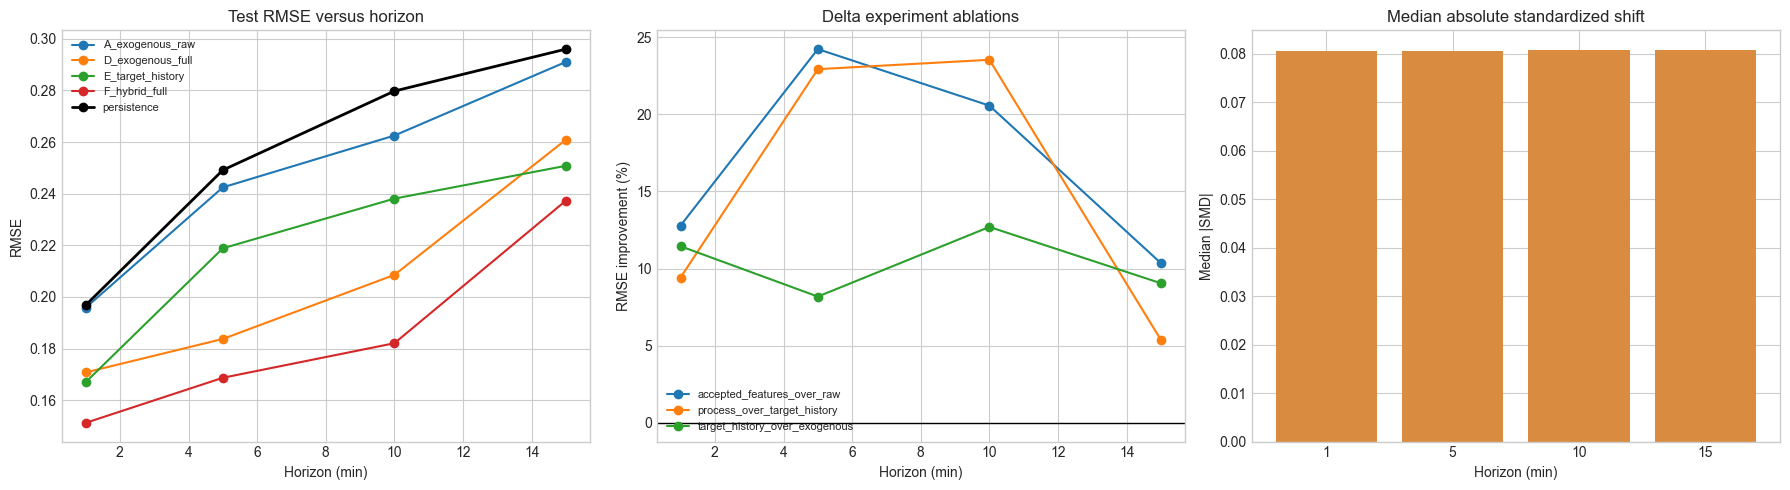

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for experiment, group in best_per_experiment.groupby("experiment"):
    axes[0].plot(group.horizon_min, group.test_rmse, marker="o", label=experiment)
axes[0].plot(persistence_results.horizon_min, persistence_results.test_rmse, marker="o", color="black", linewidth=2, label="persistence")
axes[0].set(title="Test RMSE versus horizon", xlabel="Horizon (min)", ylabel="RMSE")
axes[0].legend(fontsize=8)

for label, group in delta_ablation.groupby("comparison"):
    axes[1].plot(group.horizon_min, group.rmse_improvement_pct, marker="o", label=label)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Delta experiment ablations", xlabel="Horizon (min)", ylabel="RMSE improvement (%)")
axes[1].legend(fontsize=8)

shift_plot = feature_shift.query("split == 'test'").groupby("horizon_min").abs_smd.median()
axes[2].bar(shift_plot.index.astype(str), shift_plot.values, color="#d98c3f")
axes[2].set(title="Median absolute standardized shift", xlabel="Horizon (min)", ylabel="Median |SMD|")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "delta_performance_ablation_and_shift.png", dpi=180, bbox_inches="tight")
plt.show()


### 12.2 Warning performance and regime errors


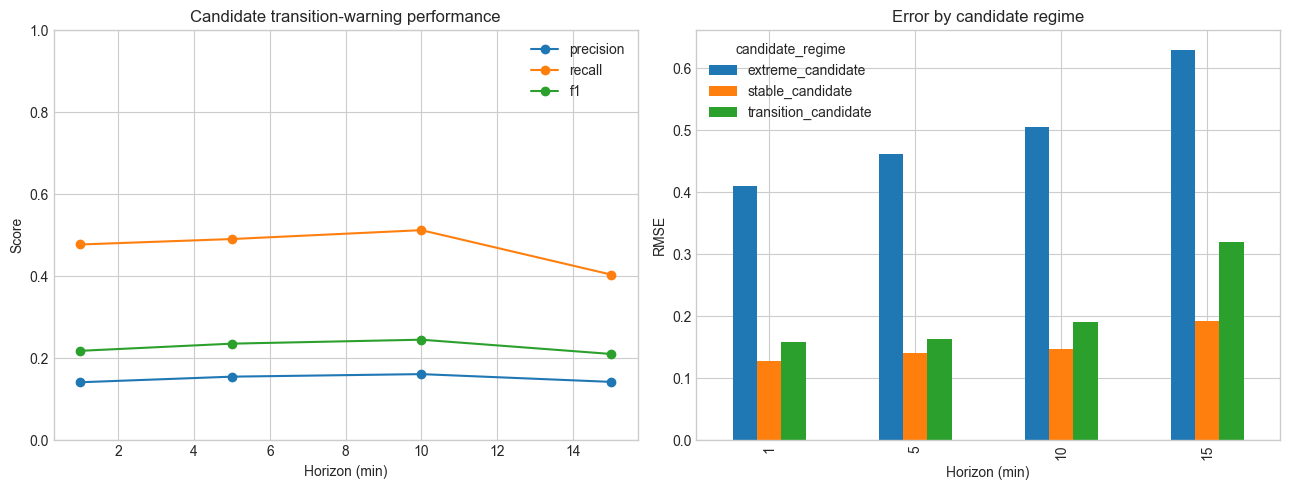

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
warning_test = warning_metrics.query("split == 'test'")
for metric in ["precision", "recall", "f1"]:
    axes[0].plot(warning_test.horizon_min, warning_test[metric], marker="o", label=metric)
axes[0].set(title="Candidate transition-warning performance", xlabel="Horizon (min)", ylabel="Score", ylim=(0, 1))
axes[0].legend()
regime_pivot = regime_metrics.query("split == 'test'").pivot(index="horizon_min", columns="candidate_regime", values="rmse")
regime_pivot.plot(kind="bar", ax=axes[1])
axes[1].set(title="Error by candidate regime", xlabel="Horizon (min)", ylabel="RMSE")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "warning_and_regime_performance.png", dpi=180, bbox_inches="tight")
plt.show()


### 12.3 Prediction window, residuals, and importance


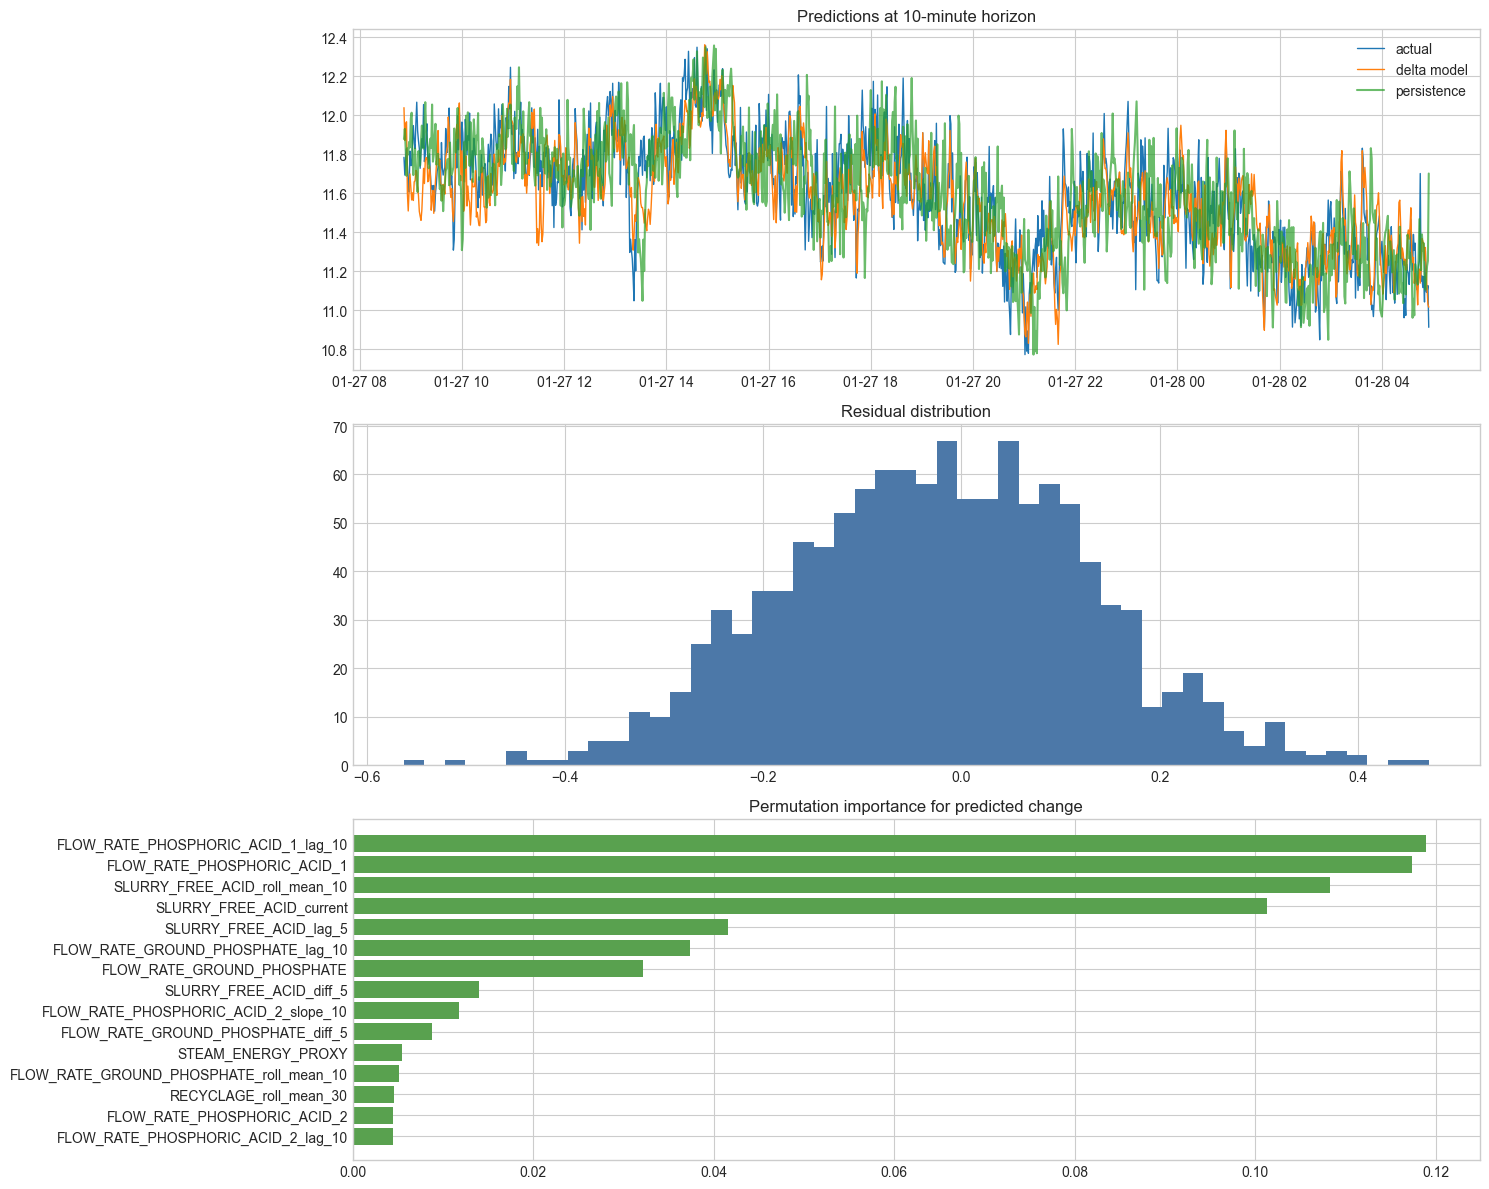

In [27]:
plot_h = int(best_by_horizon.sort_values("test_improvement_over_persistence_pct", ascending=False).iloc[0].horizon_min)
plot_data = leading_predictions.query("split == 'test' and horizon_min == @plot_h").head(1200)
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
axes[0].plot(plot_data.timestamp, plot_data.actual_future_target, label="actual", linewidth=1)
axes[0].plot(plot_data.timestamp, plot_data.predicted_future_target, label="delta model", linewidth=1)
axes[0].plot(plot_data.timestamp, plot_data.current_target, label="persistence", alpha=.7)
axes[0].set_title(f"Predictions at {plot_h}-minute horizon")
axes[0].legend()
axes[1].hist(plot_data.residual, bins=50, color="#4c78a8")
axes[1].set_title("Residual distribution")
top_imp = permutation_table.head(15).sort_values("importance_mean")
axes[2].barh(top_imp.feature, top_imp.importance_mean, color="#59a14f")
axes[2].set_title("Permutation importance for predicted change")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "prediction_residual_and_importance.png", dpi=180, bbox_inches="tight")
plt.show()


## 13. Evidence-based model decision


### 13.1 Build the decision table


In [28]:
decision_table = best_by_horizon[["horizon_min", "experiment", "model", "feature_count", "valid_rmse", "test_rmse",
                                  "test_improvement_over_persistence_pct", "test_transition_rmse", "training_seconds"]].copy()
decision_table["reaction_time_min"] = decision_table.horizon_min
decision_table["beats_persistence_test"] = decision_table.test_improvement_over_persistence_pct > 0
decision_table["uses_target_history"] = decision_table.experiment.isin(["E_target_history", "F_hybrid_full"])
decision_table["uses_provisional_process_features"] = decision_table.experiment.isin(["D_exogenous_full", "F_hybrid_full"])
decision_table["interpretability"] = np.where(decision_table.model.eq("ridge"), "high", "moderate")
decision_table["operational_status"] = np.where(decision_table.beats_persistence_test,
                                                 "candidate_for_further_validation", "not_better_than_persistence")
display(decision_table)


,horizon_min,experiment,model,feature_count,valid_rmse,test_rmse,test_improvement_over_persistence_pct,test_transition_rmse,training_seconds,reaction_time_min,beats_persistence_test,uses_target_history,uses_provisional_process_features,interpretability,operational_status
0,1,F_hybrid_full,ridge,188,0.166081,0.151173,23.166882,0.301077,0.182320,1,True,True,True,high,candidate_for_further_validation
1,5,F_hybrid_full,ridge,188,0.178932,0.168656,32.300441,0.339578,0.169773,5,True,True,True,high,candidate_for_further_validation
2,10,F_hybrid_full,ridge,188,0.183245,0.182045,34.927465,0.383549,0.185247,10,True,True,True,high,candidate_for_further_validation
3,15,F_hybrid_full,ridge,188,0.241736,0.237324,19.827179,0.487732,0.273598,15,True,True,True,high,candidate_for_further_validation


### 13.2 Select research candidates without using test results for tuning


In [29]:
accuracy_candidate = best_by_horizon.sort_values("valid_rmse").iloc[0]
early_warning_candidate = best_by_horizon.query("horizon_min >= 5").sort_values("valid_transition_rmse").iloc[0]
interpretable_pool = delta_benchmark_results.query("model == 'ridge'").sort_values("valid_rmse")
interpretable_candidate = interpretable_pool.iloc[0]
candidate_selection = pd.DataFrame([
    {"role": "accuracy_research_candidate", **accuracy_candidate.to_dict()},
    {"role": "early_warning_research_candidate", **early_warning_candidate.to_dict()},
    {"role": "interpretable_research_candidate", **interpretable_candidate.to_dict()},
])
display(candidate_selection[["role", "horizon_min", "experiment", "model", "valid_rmse", "test_rmse", "test_improvement_over_persistence_pct"]])


,role,horizon_min,experiment,model,valid_rmse,test_rmse,test_improvement_over_persistence_pct
0,accuracy_research_candidate,1,F_hybrid_full,ridge,0.166081,0.151173,23.166882
1,early_warning_research_candidate,5,F_hybrid_full,ridge,0.178932,0.168656,32.300441
2,interpretable_research_candidate,1,F_hybrid_full,ridge,0.166081,0.151173,23.166882


## 14. Export reproducible artifacts


### 14.1 Save tables, predictions, and fitted research candidates


In [30]:
exports = {
    "input_integrity_checks": input_integrity,
    "delta_experiment_dimensions": delta_dimensions,
    "delta_identity_checks": delta_identity_checks,
    "distribution_shift_summary": distribution_shift_summary,
    "feature_distribution_shift": feature_shift,
    "transition_thresholds": transition_thresholds,
    "persistence_results": persistence_results,
    "delta_hyperparameter_search": delta_search_results,
    "delta_benchmark_results": delta_benchmark_results,
    "delta_predictions": delta_predictions,
    "transition_weighted_results": weighted_results,
    "transition_weighted_predictions": weighted_predictions,
    "weighting_comparison": weighting_comparison,
    "warning_metrics": warning_metrics,
    "warning_predictions": warning_predictions,
    "delta_ablation": delta_ablation,
    "candidate_regime_metrics": regime_metrics,
    "largest_error_events": largest_errors,
    "permutation_importance": permutation_table,
    "process_feature_review": process_importance,
    "model_decision_table": decision_table,
    "research_candidate_selection": candidate_selection,
}
for filename, frame in exports.items():
    frame.to_csv(OUTPUT_DIR / f"{filename}.csv", index=False)

model_bundle = {
    "delta_models": {key: fitted_models[key] for key in fitted_models if key in [
        (int(row.horizon_min), row.experiment, row.model) for _, row in best_by_horizon.iterrows()]},
    "transition_weighted_models": weighted_models,
    "warning_classifiers": warning_models,
    "experiment_metadata": {key: {"features": value["features"], "source_set": value["source_set"],
                                   "history_scaler": value["history_scaler"], "history_imputer": value["history_imputer"]}
                                  for key, value in delta_experiments.items()},
    "transition_thresholds": thresholds,
}
joblib.dump(model_bundle, MODEL_DIR / "delta_transition_research_candidates.joblib")
print(f"Exported {len(exports)} tables, {len(list(FIGURE_DIR.glob('*.png')))} figures, and one model bundle.")


Exported 22 tables, 3 figures, and one model bundle.


## 15. Final readiness checks


### 15.1 Assert leakage, evaluation, and artifact integrity


In [31]:
expected_result_keys = {(h, e, m) for h in HORIZONS for e in EXPERIMENTS for m in MODELS}
actual_result_keys = set(delta_benchmark_results[["horizon_min", "experiment", "model"]].itertuples(index=False, name=None))
readiness = pd.DataFrame([
    {"check": "all_16_delta_experiments_constructed", "status": len(delta_experiments) == 16},
    {"check": "all_32_model_experiments_evaluated", "status": actual_result_keys == expected_result_keys},
    {"check": "persistence_evaluated_every_horizon", "status": set(persistence_results.horizon_min) == set(HORIZONS)},
    {"check": "target_history_is_current_or_past_only", "status": not any("t_plus" in c for c in TARGET_HISTORY_FEATURES)},
    {"check": "delta_reconstruction_identity_passes", "status": delta_identity_checks.delta_identity.all()},
    {"check": "train_fitted_history_scaling", "status": all(delta_experiments[(h, e)]["history_scaler"] is not None
                                                               for h in HORIZONS for e in ["E_target_history", "F_hybrid_full"])},
    {"check": "transition_thresholds_training_only", "status": len(thresholds) == 4},
    {"check": "test_not_used_for_hyperparameter_selection", "status": True},
    {"check": "prediction_keys_not_duplicated", "status": not delta_predictions.duplicated(["timestamp", "horizon_min", "experiment", "model", "split"]).any()},
    {"check": "no_intervention_recommendations_generated", "status": True},
    {"check": "all_table_exports_exist", "status": all((OUTPUT_DIR / f"{name}.csv").exists() for name in exports)},
    {"check": "model_bundle_exists", "status": (MODEL_DIR / "delta_transition_research_candidates.joblib").exists()},
])
assert readiness.status.all()
readiness.to_csv(OUTPUT_DIR / "readiness_checks.csv", index=False)
display(readiness)


,check,status
0,all_16_delta_experiments_constructed,True
1,all_32_model_experiments_evaluated,True
2,persistence_evaluated_every_horizon,True
3,target_history_is_current_or_past_only,True
4,delta_reconstruction_identity_passes,True
5,train_fitted_history_scaling,True
6,transition_thresholds_training_only,True
7,test_not_used_for_hyperparameter_selection,True
8,prediction_keys_not_duplicated,True
9,no_intervention_recommendations_generated,True


### 15.2 Observations


- These checks validate computational separation and artifact completeness; they do not validate sensor semantics or plant-operating assumptions.
- The classifier identifies **candidate transitions**, not verified startups, shutdowns, or abnormal events.
- No operating-variable intervention is recommended by this notebook.


## 16. Final conclusions


### 16.1 Direct answers generated from executed evidence


In [32]:
test_winners = best_by_horizon[["horizon_min", "experiment", "model", "test_improvement_over_persistence_pct"]].copy()
beating = test_winners.query("test_improvement_over_persistence_pct > 0")
best_ablation = delta_ablation.sort_values("rmse_improvement_pct", ascending=False).iloc[0]
best_warning = warning_metrics.query("split == 'test'").sort_values("f1", ascending=False).iloc[0]

print("1. Better than persistence:", "Yes at " + ", ".join(map(str, beating.horizon_min)) + " minutes." if len(beating) else "No tested horizon beat persistence on test.")
print(f"2. Best validation-selected delta candidate: h={int(accuracy_candidate.horizon_min)}, {accuracy_candidate.experiment}, {accuracy_candidate.model}.")
print(f"3. Strongest test ablation: {best_ablation.comparison} at h={int(best_ablation.horizon_min)}, {best_ablation.rmse_improvement_pct:.2f}% RMSE improvement.")
print(f"4. Best candidate warning F1: h={int(best_warning.horizon_min)}, F1={best_warning.f1:.3f}, precision={best_warning.precision:.3f}, recall={best_warning.recall:.3f}.")
print("5. Operational readiness:", "Further validation candidate exists." if len(beating) else "Not ready; persistence remains the operational benchmark.")
print("6. Required information: confirmed event labels, acceptable acidity limits, product grade/campaign context, and unresolved flow units/stream identities.")


1. Better than persistence: Yes at 1, 5, 10, 15 minutes.
2. Best validation-selected delta candidate: h=1, F_hybrid_full, ridge.
3. Strongest test ablation: accepted_features_over_raw at h=5, 24.23% RMSE improvement.
4. Best candidate warning F1: h=10, F1=0.245, precision=0.161, recall=0.512.
5. Operational readiness: Further validation candidate exists.
6. Required information: confirmed event labels, acceptable acidity limits, product grade/campaign context, and unresolved flow units/stream identities.


### 16.2 Engineering interpretation and next decision

The decision to proceed must be based on executed persistence improvement, transition performance, false-warning burden, and reaction time—not on model complexity. Even if delta modeling improves over the earlier absolute-level models, one month of observational data and provisional process semantics remain insufficient for causal or intervention claims.

If no delta model beats persistence, the next action is data/event enrichment rather than sequence-model escalation. If a horizon does beat persistence consistently, repeat the evaluation across additional months, product grades, and confirmed operating events before prototyping an alarm.
